<a href="https://colab.research.google.com/github/OJB-Quantum/Math-and-Physics-How-To/blob/main/Quantum_Stuffy_Scaffold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

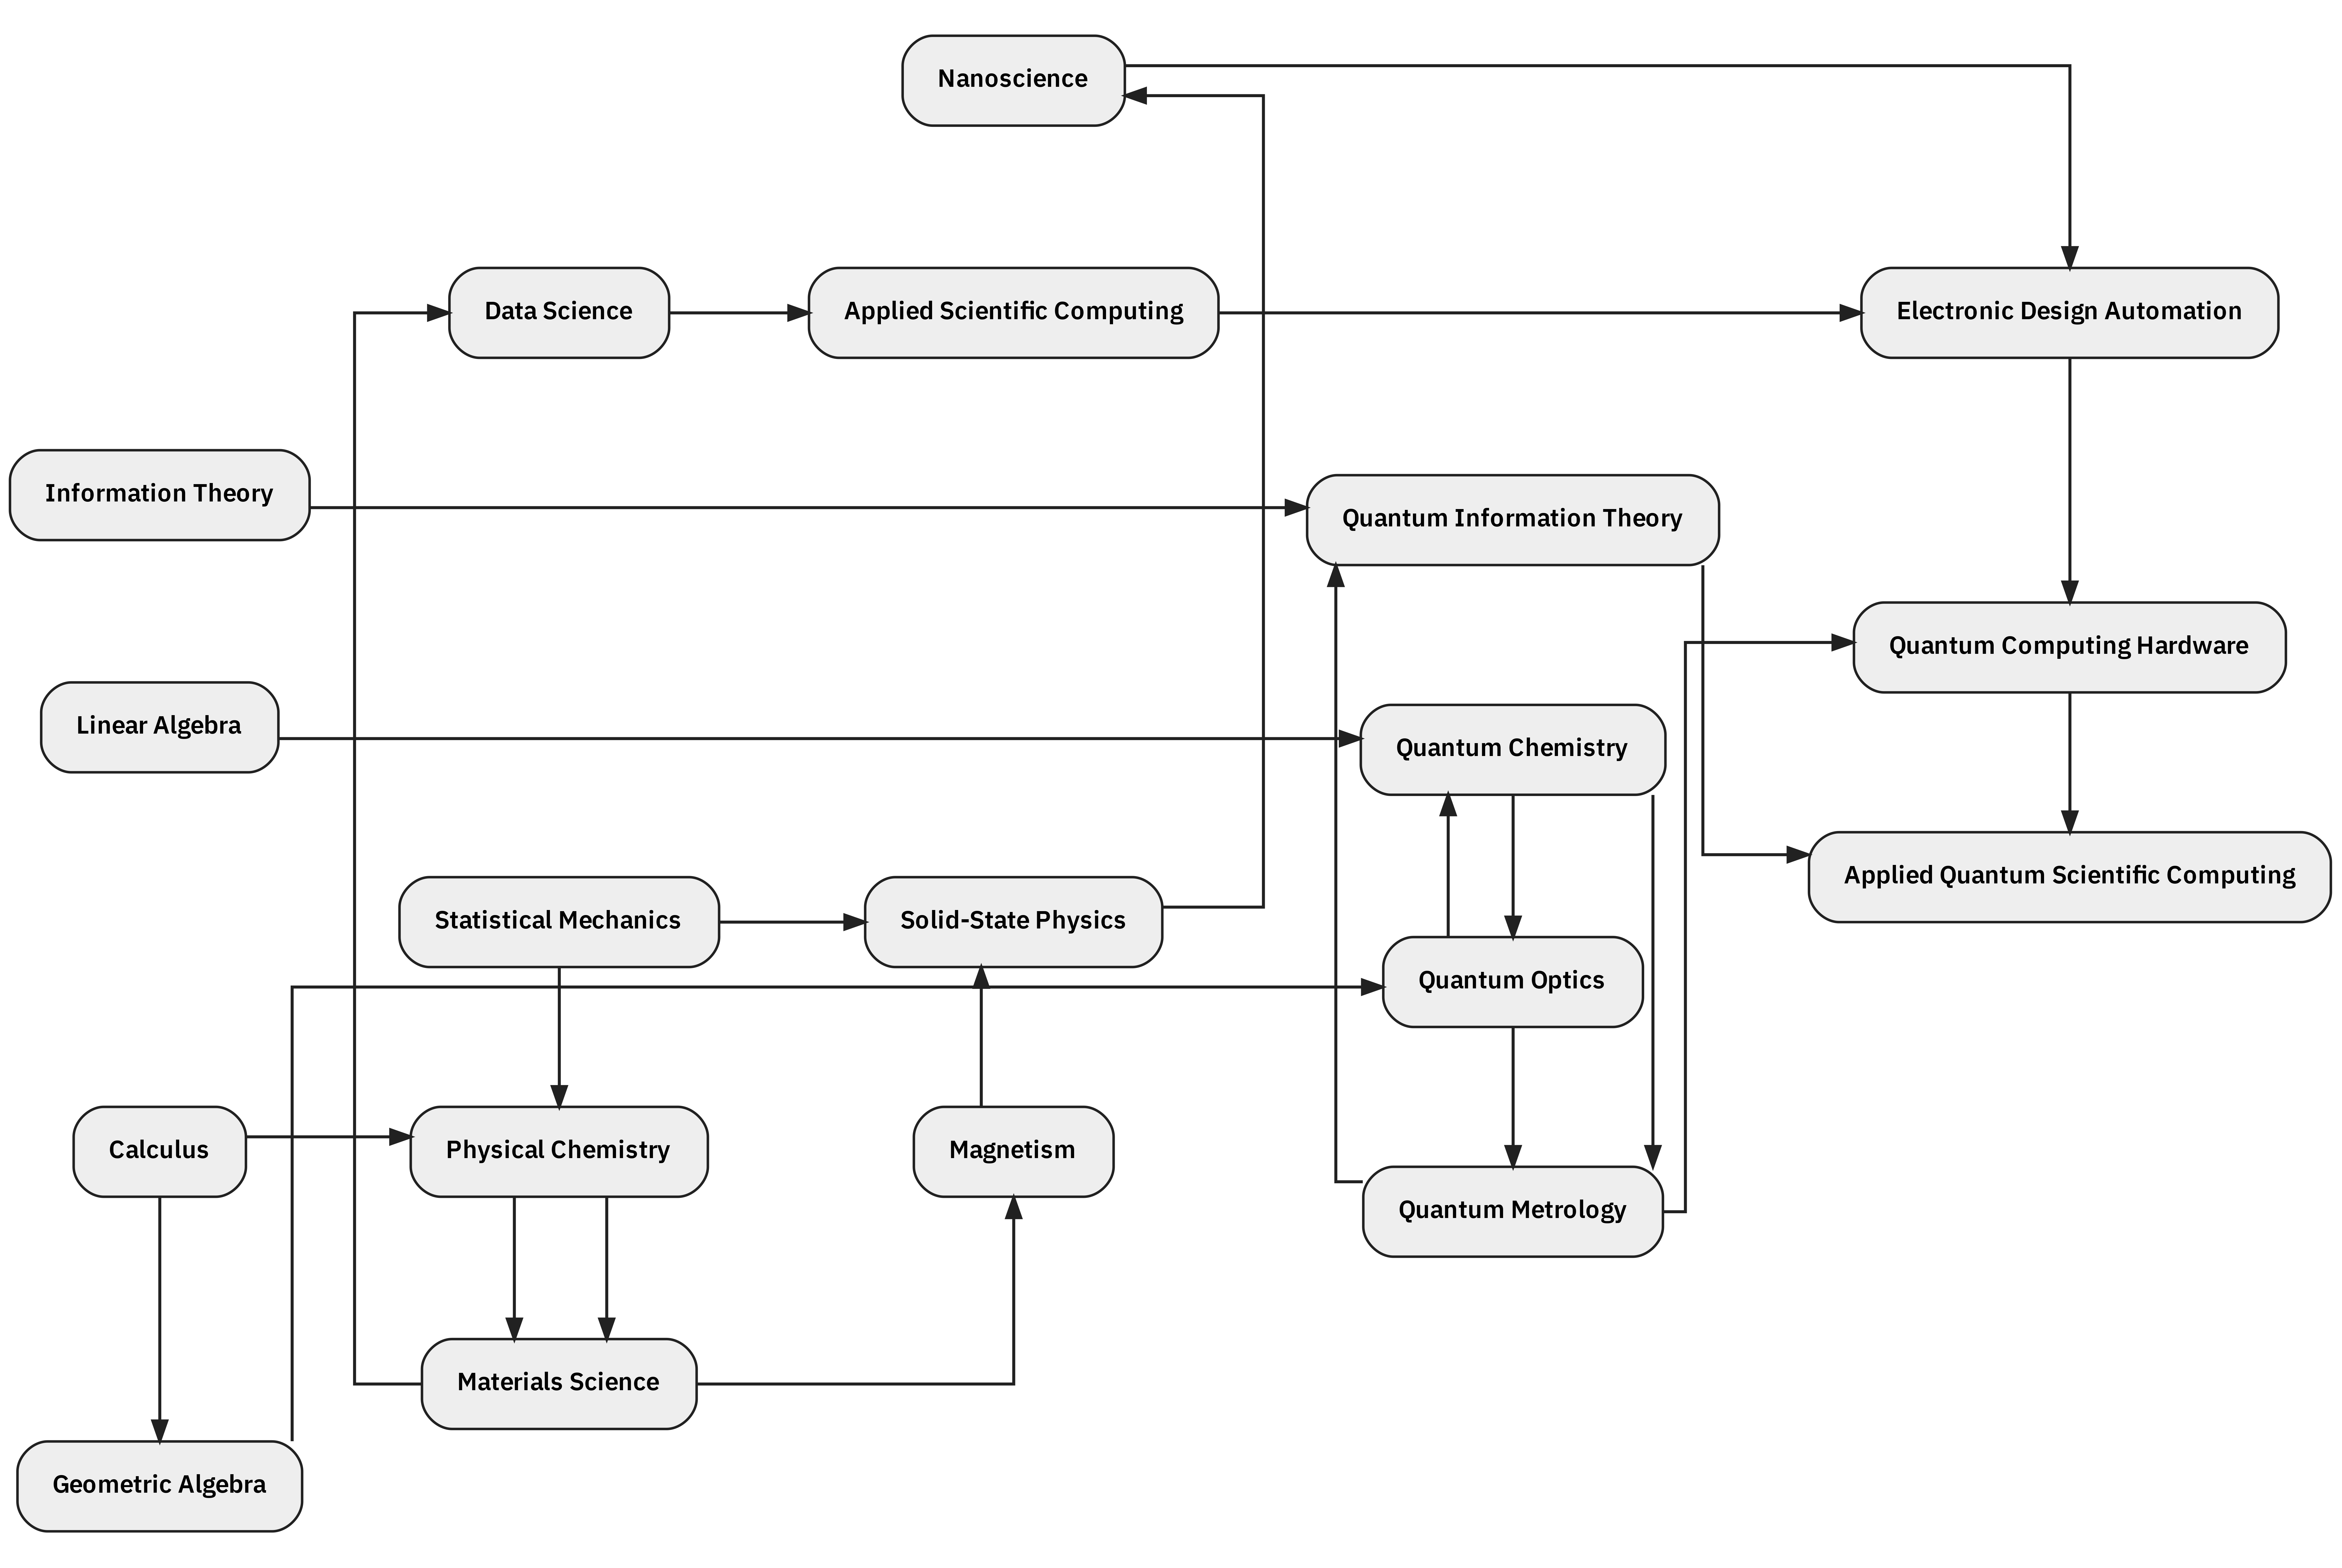

In [10]:
import graphviz
from IPython.display import display, Image

# Global font specifications
FONT_REGULAR = "IBM Plex Sans"
FONT_BOLD = "IBM Plex Sans Semibold"
DPI = "800"
GRAPH_SIZE = "10.5,7.0!"  # Controls overall output dimension in inches (3:2)

# --- Define the visual theme ---
theme_attrs = {
    'graph_attr': {
        'rankdir': 'LR',  # Left-to-Right within rows
        'dpi': DPI,
        'size': GRAPH_SIZE,
        'ratio': 'fill',
        'nodesep': '0.3',
        'ranksep': '0.5',
        'bgcolor': 'white',
        'fontname': FONT_REGULAR,
        'splines': 'ortho'  # Clean orthogonal lines for serpentine flow
    },
    'node_attr': {
        'shape': 'box',
        'style': 'filled, rounded',
        'color': '#212121',  # Border color
        'fillcolor': '#EEEEEE',  # Node background
        'fontname': FONT_REGULAR,
        'fontsize': '10',
        'margin': '0.2,0.1'
    },
    'edge_attr': {
        'color': '#212121',
        'arrowsize': '0.8',
        'penwidth': '1.2'
    }
}

def apply_theme(g):
    """Applies a consistent theme to the graph and all subgraphs."""
    g.graph_attr.update(theme_attrs['graph_attr'])
    g.node_attr.update(theme_attrs['node_attr'])
    g.edge_attr.update(theme_attrs['edge_attr'])
    return g

def create_serpentine_scaffold():
    # Initialize the main graph and apply global theme
    main_g = graphviz.Digraph(comment='Quantum Serpentine Scaffold')
    apply_theme(main_g)

    # Use HTML labels to specify the semibold font for node text
    def bold_label(text):
        return f'<<FONT FACE="{FONT_BOLD}">{text}</FONT>>'

    # --- Group topics into tiers (ranks) to create rows ---

    # Tier 1: Mathematical Foundations (Left to Right)
    with main_g.subgraph(name='tier1') as s1:
        s1.attr(rank='same')
        s1.node('Calc', bold_label('Calculus'))
        s1.node('LA', bold_label('Linear Algebra'))
        s1.node('GA', bold_label('Geometric Algebra'))
        s1.node('Info', bold_label('Information Theory'))

    # Tier 2: Classical & Statistical physical Sciences (Right to Left)
    with main_g.subgraph(name='tier2') as s2:
        s2.attr(rank='same')
        s2.node('StatMech', bold_label('Statistical Mechanics'))
        s2.node('PhysChem', bold_label('Physical Chemistry'))
        s2.node('MatSci', bold_label('Materials Science'))
        s2.node('DataSci', bold_label('Data Science'))

    # Tier 3: Core Applied Physics & Computation (Left to Right)
    with main_g.subgraph(name='tier3') as s3:
        s3.attr(rank='same')
        s3.node('ASC', bold_label('Applied Scientific Computing'))
        s3.node('Magnetism', bold_label('Magnetism'))
        s3.node('SSP', bold_label('Solid-State Physics'))
        s3.node('Nano', bold_label('Nanoscience'))

    # Tier 4: Quantum & Advanced Applied Fields (Right to Left)
    with main_g.subgraph(name='tier4') as s4:
        s4.attr(rank='same')
        s4.node('Qoptics', bold_label('Quantum Optics'))
        s4.node('Qchem', bold_label('Quantum Chemistry'))
        s4.node('Qmet', bold_label('Quantum Metrology'))
        s4.node('QIT', bold_label('Quantum Information Theory'))

    # Tier 5: Complete System Synthesis (Left to Right)
    with main_g.subgraph(name='tier5') as s5:
        s5.attr(rank='same')
        s5.node('AQSC', bold_label('Applied Quantum Scientific Computing'))
        s5.node('QCH', bold_label('Quantum Computing Hardware'))
        s5.node('EDA', bold_label('Electronic Design Automation'))

    # --- Draw invisible vertical edges to enforce row sequence ---
    # Calc -> PhysChem -> SSP -> Qoptics -> AQSC
    # (Choosing one vertical pair per transition)
    main_g.edge('Calc', 'PhysChem', style='invis')
    main_g.edge('PhysChem', 'Magnetism', style='invis')
    main_g.edge('Magnetism', 'Qoptics', style='invis')
    main_g.edge('Qoptics', 'AQSC', style='invis')

    # --- Internal tier edges (for explicit flow control) ---
    # In 'LR' rankdir, we must define reverse edges for tiers 2 and 4 to render Right-to-Left
    main_g.edge('StatMech', 'PhysChem', constraint='false', minlen='1')
    main_g.edge('PhysChem', 'MatSci', constraint='false', minlen='1')
    main_g.edge('MatSci', 'DataSci', constraint='false', minlen='1')
    main_g.edge('Qoptics', 'Qchem', constraint='false', minlen='1')
    main_g.edge('Qchem', 'Qmet', constraint='false', minlen='1')
    main_g.edge('Qmet', 'QIT', constraint='false', minlen='1')

    # --- Define all prerequisite/dependency logical flow ---
    # The graph ranks will keep topics in rows, these edges define logical prerequisite paths.
    dependencies = [
        # Math -> Applied Math/Theory
        ('Calc', 'GA'),
        ('LA', 'Qchem'),
        ('Info', 'QIT'),

        # Physical Sciences Prereqs
        ('Calc', 'PhysChem'),
        ('PhysChem', 'MatSci'),
        ('StatMech', 'SSP'),

        # Materials & Nanotechnology Path
        ('MatSci', 'Magnetism'),
        ('Magnetism', 'SSP'),
        ('SSP', 'Nano'),
        ('Nano', 'EDA'),

        # Data & Computing Foundations
        ('DataSci', 'ASC'),
        ('ASC', 'EDA'),

        # Intermediate/Advanced Quantum
        ('GA', 'Qoptics'),
        ('Qchem', 'Qoptics'),
        ('QIT', 'AQSC'),
        ('Qoptics', 'Qmet'),

        # Complete System Level
        ('Qmet', 'QCH'),
        ('EDA', 'QCH'),
        ('QCH', 'AQSC')
    ]

    for start, end in dependencies:
        main_g.edge(start, end)

    return main_g

# Execute the graph creation
full_scaffold_graph = create_serpentine_scaffold()

# Render directly to the screen. The display function in Jupyter/Colab
# renders the PNG image with the requested resolution in the output.
png_output = full_scaffold_graph.pipe(format='png')
display(Image(data=png_output, embed=True))

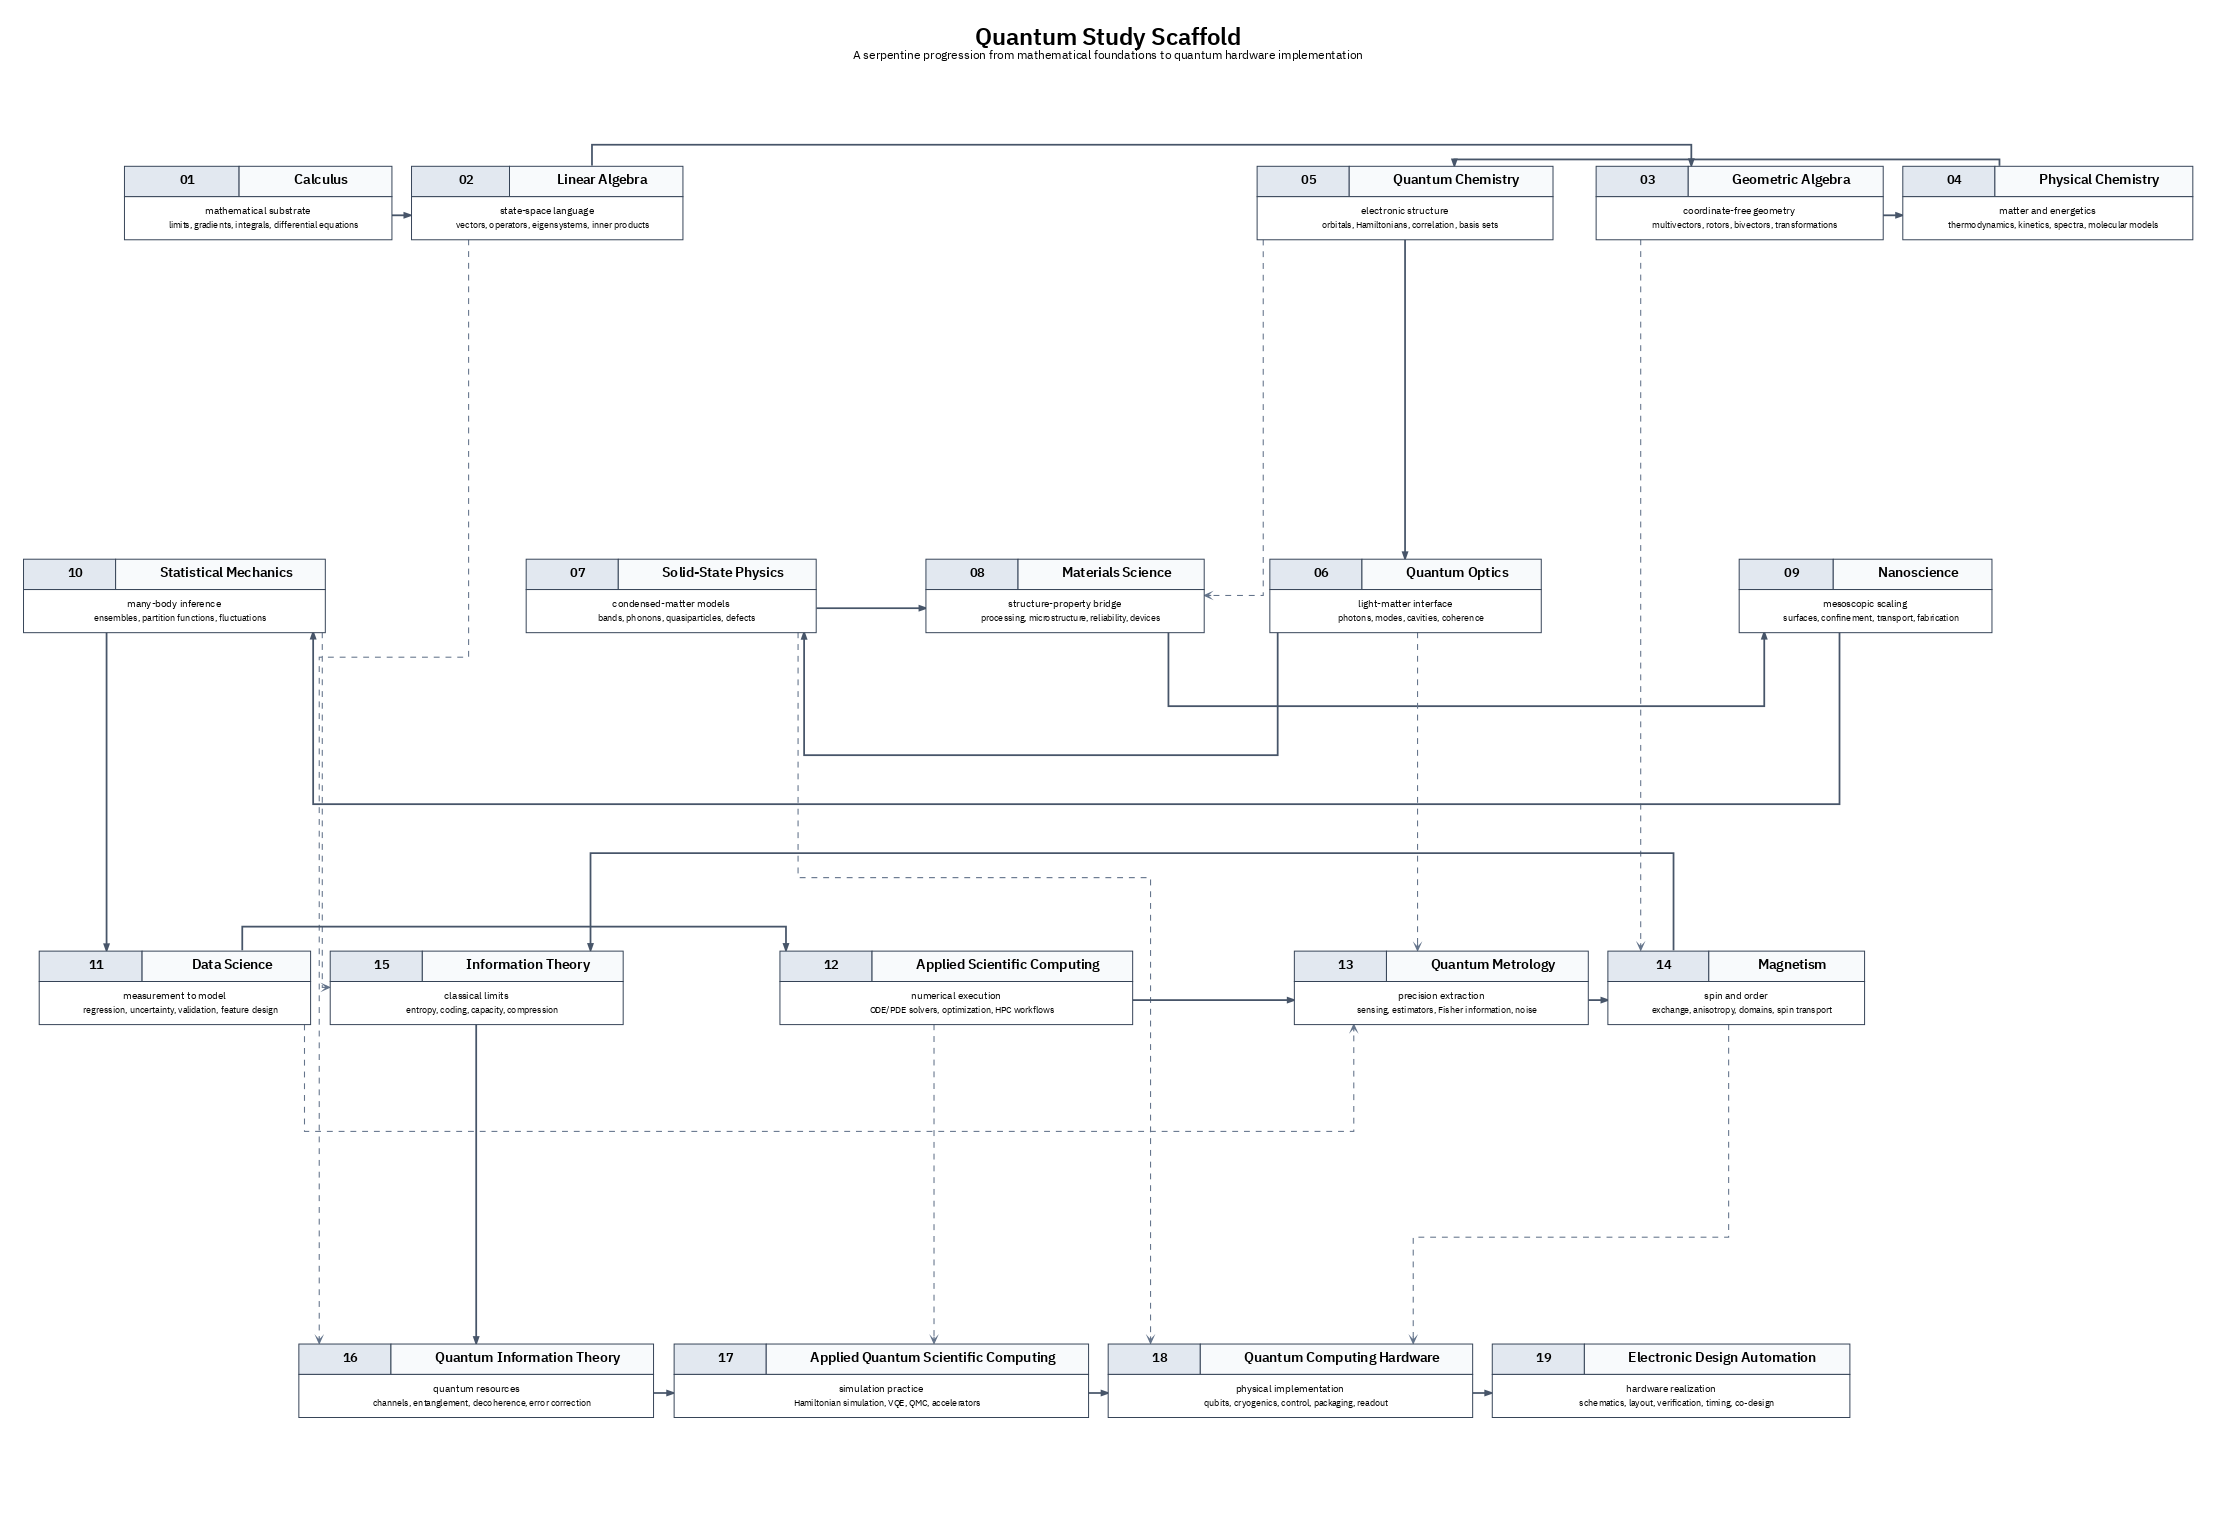

PNG written to /content/quantum_study_scaffold_serpentine.png


In [9]:
# @title Quantum study scaffold flowchart with Graphviz

# Control knobs
DPI = 250
CANVAS_INCHES = (9.0, 6.0)  # 3:2 aspect ratio
DISPLAY_WIDTH_PX = 1200
COLUMNS_PER_ROW = 5
OUTPUT_DIR = "/content"
OUTPUT_STEM = "quantum_study_scaffold_serpentine"

FONT_NORMAL = "IBM Plex Sans"
FONT_BOLD = "IBM Plex Sans Semibold"

NODE_BORDER = "#334155"
NODE_FILL = "#F8FAFC"
NODE_STEP_FILL = "#E2E8F0"
EDGE_COLOR = "#475569"
CROSSLINK_COLOR = "#64748B"

INSTALL_DEPENDENCIES = True
INSTALL_SYSTEM_GRAPHVIZ = True
INSTALL_IBM_PLEX_FONT = True

import html
import subprocess
from pathlib import Path

if INSTALL_DEPENDENCIES:
    subprocess.run(
        ["python", "-m", "pip", "install", "-q", "uv"],
        check=True,
    )
    subprocess.run(
        ["uv", "pip", "install", "--system", "-q", "graphviz"],
        check=True,
    )

if INSTALL_SYSTEM_GRAPHVIZ:
    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
        stdout=subprocess.DEVNULL,
    )
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "graphviz"],
        check=True,
    )

if INSTALL_IBM_PLEX_FONT:
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "fonts-ibm-plex"],
        check=False,
    )
    subprocess.run(["fc-cache", "-f"], check=False)

from graphviz import Digraph
from IPython.display import Image, display


def make_node_id(index):
    """Return a stable Graphviz node identifier."""
    return f"step_{index:02d}"


def pairwise(items):
    """Yield adjacent pairs from a sequence."""
    return zip(items[:-1], items[1:])


def make_html_label(step, title, phase, focus):
    """Build a compact HTML-like Graphviz label."""
    safe_title = html.escape(title)
    safe_phase = html.escape(phase)
    safe_focus = html.escape(focus)

    return f"""<
<TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" CELLPADDING="7" COLOR="{NODE_BORDER}">
    <TR>
        <TD BGCOLOR="{NODE_STEP_FILL}">
            <FONT FACE="{FONT_BOLD}" POINT-SIZE="13">{step:02d}</FONT>
        </TD>
        <TD BGCOLOR="{NODE_FILL}">
            <FONT FACE="{FONT_BOLD}" POINT-SIZE="14">{safe_title}</FONT>
        </TD>
    </TR>
    <TR>
        <TD COLSPAN="2" BGCOLOR="white">
            <FONT FACE="{FONT_NORMAL}" POINT-SIZE="10">{safe_phase}</FONT>
            <BR/>
            <FONT FACE="{FONT_NORMAL}" POINT-SIZE="9">{safe_focus}</FONT>
        </TD>
    </TR>
</TABLE>
>"""


topics = [
    {
        "title": "Calculus",
        "phase": "mathematical substrate",
        "focus": "limits, gradients, integrals, differential equations",
    },
    {
        "title": "Linear Algebra",
        "phase": "state-space language",
        "focus": "vectors, operators, eigensystems, inner products",
    },
    {
        "title": "Geometric Algebra",
        "phase": "coordinate-free geometry",
        "focus": "multivectors, rotors, bivectors, transformations",
    },
    {
        "title": "Physical Chemistry",
        "phase": "matter and energetics",
        "focus": "thermodynamics, kinetics, spectra, molecular models",
    },
    {
        "title": "Quantum Chemistry",
        "phase": "electronic structure",
        "focus": "orbitals, Hamiltonians, correlation, basis sets",
    },
    {
        "title": "Quantum Optics",
        "phase": "light-matter interface",
        "focus": "photons, modes, cavities, coherence",
    },
    {
        "title": "Solid-State Physics",
        "phase": "condensed-matter models",
        "focus": "bands, phonons, quasiparticles, defects",
    },
    {
        "title": "Materials Science",
        "phase": "structure-property bridge",
        "focus": "processing, microstructure, reliability, devices",
    },
    {
        "title": "Nanoscience",
        "phase": "mesoscopic scaling",
        "focus": "surfaces, confinement, transport, fabrication",
    },
    {
        "title": "Statistical Mechanics",
        "phase": "many-body inference",
        "focus": "ensembles, partition functions, fluctuations",
    },
    {
        "title": "Data Science",
        "phase": "measurement to model",
        "focus": "regression, uncertainty, validation, feature design",
    },
    {
        "title": "Applied Scientific Computing",
        "phase": "numerical execution",
        "focus": "ODE/PDE solvers, optimization, HPC workflows",
    },
    {
        "title": "Quantum Metrology",
        "phase": "precision extraction",
        "focus": "sensing, estimators, Fisher information, noise",
    },
    {
        "title": "Magnetism",
        "phase": "spin and order",
        "focus": "exchange, anisotropy, domains, spin transport",
    },
    {
        "title": "Information Theory",
        "phase": "classical limits",
        "focus": "entropy, coding, capacity, compression",
    },
    {
        "title": "Quantum Information Theory",
        "phase": "quantum resources",
        "focus": "channels, entanglement, decoherence, error correction",
    },
    {
        "title": "Applied Quantum Scientific Computing",
        "phase": "simulation practice",
        "focus": "Hamiltonian simulation, VQE, QMC, accelerators",
    },
    {
        "title": "Quantum Computing Hardware",
        "phase": "physical implementation",
        "focus": "qubits, cryogenics, control, packaging, readout",
    },
    {
        "title": "Electronic Design Automation",
        "phase": "hardware realization",
        "focus": "schematics, layout, verification, timing, co-design",
    },
]

node_ids = [make_node_id(index + 1) for index in range(len(topics))]
row_by_node = {}
visual_rows = []

for row_index, start in enumerate(range(0, len(node_ids), COLUMNS_PER_ROW)):
    chunk = node_ids[start:start + COLUMNS_PER_ROW]
    visual_row = chunk if row_index % 2 == 0 else list(reversed(chunk))
    visual_rows.append(visual_row)

    for node_id in chunk:
        row_by_node[node_id] = row_index

dot = Digraph(
    name="quantum_study_scaffold",
    engine="dot",
    format="png",
)

dot.attr(
    "graph",
    bgcolor="white",
    dpi=str(DPI),
    fontname=FONT_NORMAL,
    label=(
        f'<\n'
        f'<FONT FACE="{FONT_BOLD}" POINT-SIZE="24">'
        f'Quantum Study Scaffold'
        f'</FONT>'
        f'<BR/>'
        f'<FONT FACE="{FONT_NORMAL}" POINT-SIZE="12">'
        f'A serpentine progression from mathematical foundations to quantum hardware implementation'
        f'</FONT>\n'
        f'>'
    ),
    labelloc="t",
    margin="0.08",
    nodesep="0.28",
    outputorder="edgesfirst",
    pad="0.05",
    rankdir="TB",
    ranksep="0.46",
    ratio="fill",
    size=f"{CANVAS_INCHES[0]},{CANVAS_INCHES[1]}!",
    splines="ortho",
)

dot.attr(
    "node",
    fontname=FONT_NORMAL,
    margin="0",
    shape="plain",
)

dot.attr(
    "edge",
    arrowsize="0.65",
    color=EDGE_COLOR,
    fontname=FONT_NORMAL,
    penwidth="1.6",
)

for row_index, visual_row in enumerate(visual_rows):
    with dot.subgraph(name=f"row_{row_index}") as row_graph:
        row_graph.attr(rank="same")

        for node_id in visual_row:
            topic_index = node_ids.index(node_id)
            topic = topics[topic_index]
            label = make_html_label(
                step=topic_index + 1,
                title=topic["title"],
                phase=topic["phase"],
                focus=topic["focus"],
            )
            row_graph.node(node_id, label=label)

    for left_node, right_node in pairwise(visual_row):
        dot.edge(
            left_node,
            right_node,
            style="invis",
            weight="100",
            constraint="false",
        )

for source_node, target_node in pairwise(node_ids):
    same_row = row_by_node[source_node] == row_by_node[target_node]
    dot.edge(
        source_node,
        target_node,
        color=EDGE_COLOR,
        constraint="false" if same_row else "true",
        penwidth="1.8",
        weight="8" if same_row else "20",
    )

crosslinks = [
    ("step_02", "step_16"),  # Linear Algebra to Quantum Information Theory
    ("step_03", "step_14"),  # Geometric Algebra to Magnetism
    ("step_05", "step_08"),  # Quantum Chemistry to Materials Science
    ("step_06", "step_13"),  # Quantum Optics to Quantum Metrology
    ("step_07", "step_18"),  # Solid-State Physics to Quantum Computing Hardware
    ("step_10", "step_15"),  # Statistical Mechanics to Information Theory
    ("step_11", "step_13"),  # Data Science to Quantum Metrology
    ("step_12", "step_17"),  # Scientific Computing to Quantum Scientific Computing
    ("step_14", "step_18"),  # Magnetism to Quantum Computing Hardware
]

for source_node, target_node in crosslinks:
    dot.edge(
        source_node,
        target_node,
        arrowhead="vee",
        color=CROSSLINK_COLOR,
        constraint="false",
        penwidth="1.1",
        style="dashed",
    )

output_path = Path(OUTPUT_DIR) / OUTPUT_STEM
png_path = dot.render(str(output_path), cleanup=True)

display(Image(filename=png_path, width=DISPLAY_WIDTH_PX))
print(f"PNG written to {png_path}")